# CausalBridges-00 — Du graphe causal a l'echelle de Pearl (socle introductif)

[← Causal-Bridges](../README.md) | [↑ DecisionTheory](../README.md) | [Suivant: CausalBridges-01 →](CausalBridges-01-Do-Calculus.ipynb)

**Pli 1 de l'Origami causal** (EPIC #19309, sous-issue #19310). Ce carnet est le **socle** : il pose le vocabulaire commun (DAG, P(Y|X) vs P(Y|do(X)), contrefactuel individuel) que les 8 plis suivants (CB-01..CB-08) supposent acquis. C'est aussi une **entree en matiere** : on ne demande pas au lecteur de savoir ce qu'est un do-calculus, on lui montre pourquoi l'observation seule est piégeuse, puis on pose la grammaire.

## Objectifs d'apprentissage

A l'issue de ce carnet, le lecteur est capable de :

1. **Reconnaitre** une situation ou l'observation seule est piegeuse (Snow/cholera 1854, Doll-Hill 1950) et nommer ce que la causalite ajoute au raisonnement.
2. **Dessiner** un DAG a 4 noeuds (Z confondeur, X traitement, M mediateur, Y outcome) avec `networkx`, et **lire** les chemins ouverts/fermes qui produisent une confusion.
3. **Distinguer** P(Y|X) de P(Y|do(X)) sur un DGP semi-synthetique, et **verifier** le theoremes d'ajustement backdoor : P(Y|do(X=1)) = E_Z[P(Y|X=1, Z)] quand Z est un ensemble de backdoor valide.
4. **Calculer** un contrefactuel individuel P(Y_x | x_0, y_0) par abduction-action-prediction (Pearl §9) sur un exemple a 1 individu.
5. **Reconnaitre** le paradoxe de Simpson (effet qui s'inverse en agregeant) et replacer les trois niveaux (observation, intervention, contrefactuel) sur l'echelle de Pearl.

## Navigation

1. **Motivation historique** : Snow, Doll-Hill — pourquoi l'observation seule echoue.
2. **DAG 4 noeuds** : Z -> X, X -> M -> Y, Z -> Y (mentorat / effort / score).
3. **P(Y|X)** : association naive, mesuree sur un DGP semi-synthetique.
4. **P(Y|do(X))** : intervention par mutilation du graphe (Pearl §3.3) ; ajustement backdoor.
5. **Contrefactuel individuel** : P(Y_x | x_0, y_0) par abduction-action-prediction (Pearl §9).
6. **Cinq exercices** : etendre le DAG, paradoxe de Simpson, contrefactuel inverse, etc.

**Duree estimee** : 45 min (lecture + execution) ; 1h30 avec les exercices.

**Prerequis** : probabilites conditionnelles, notions de graphe (noeuds, aretes orientes).

**Stack** : Python 3, `numpy`, `scipy`, `networkx`, `matplotlib`. Aucun GPU. Aucun appel reseau.

## 1. Motivation historique — quand l'observation seule est piegeuse

### 1.1. John Snow et le cholera de Broad Street (1854)

A Londres, en septembre 1854, une epidemie de cholera eclate dans le quartier de Soho. Snow cartographie les deces et constate qu'ils se concentrent autour de la **pompe de Broad Street**. La **theorie des miasmes** (l'air empeste) etait alors dominante, mais Snow defend l'hypothese que le cholera se transmet par l'eau contaminee. La cle n'est pas la correlation (beaucoup de personnes buvant l'eau de la pompe tomberaient malades, par hasard) mais le **mecanisme causal** : la pompe approvisionne un puits contamine par une fosse septique voisine ; couper la poignee de la pompe stoppe l'epidemie.

L'**observation pure** (qui tombe malade ?) n'aurait pas suffi : les gens qui boivent l'eau de la pompe sont aussi ceux qui habitent le quartier, et la pauvrete, la nourriture, l'age, le sexe, le metier sont des **confondeurs** (variables qui causent a la fois l'exposition et la maladie). Ce n'est qu'en **intervenant** (couper la pompe, puis observer) que Snow tranche entre les theories.

### 1.2. Doll et Hill, tabac et cancer du poumon (1950)

Dans les annees 1940-50, la correlation entre tabac et cancer du poumon etait massive (les fumeurs ont 10 a 30 fois plus de cancers). La reponse initiale des cigarettiers : il existe un **genotype commun** qui predispose a la fois au desir de fumer et au cancer — la correlation est donc triviale, pas causale. Doll et Hill repondent par une **etude de cohorte** sur 40 000 medecins britanniques : ceux qui ont **arrete** de fumer voient leur risque chuter en quelques annees, et ce d'autant plus que l'arret est ancien. C'est une **intervention naturelle** (l'arret) qui decoince le confounding hypothesique.

Le cas est reste celebre parce que l'**experience randomisee** n'etait pas ethiquement possible (on ne peut pas forcer des gens a fumer pendant 20 ans) — il a fallu raisonner causalement sur une observation, en controlant les confondeurs mesurables et en invoquant la **plausibilite biologique** (le mecanisme cancérogène est aujourd'hui etabli au niveau cellulaire).

### 1.3. La lecon commune : voir ne suffit pas

Dans les deux cas, l'**observation conditionnelle** (P(Y|X)) etait trompeuse : Snow voyait les deces pres de la pompe, Doll voyait les cancers chez les fumeurs. C'est l'**intervention** (couper la pompe, arreter de fumer) qui transforme une correlation en un fait causal. La causalite n'est pas un raffinement statistique — c'est un changement de **mode d'interrogation** : au lieu de demander *que vois-je quand X se produit ?*, on demande *que se passerait-il si je fixais X a une valeur ?*.

Taux de cholera par quartier (DGP illustre) :
  Soho (pompe Broad)                  : 9.10 %
  Bloomsbury (autre pompe)            : 0.40 %
  Westminster (riviere)               : 0.90 %
  Camden (puits profond)              : 0.10 %


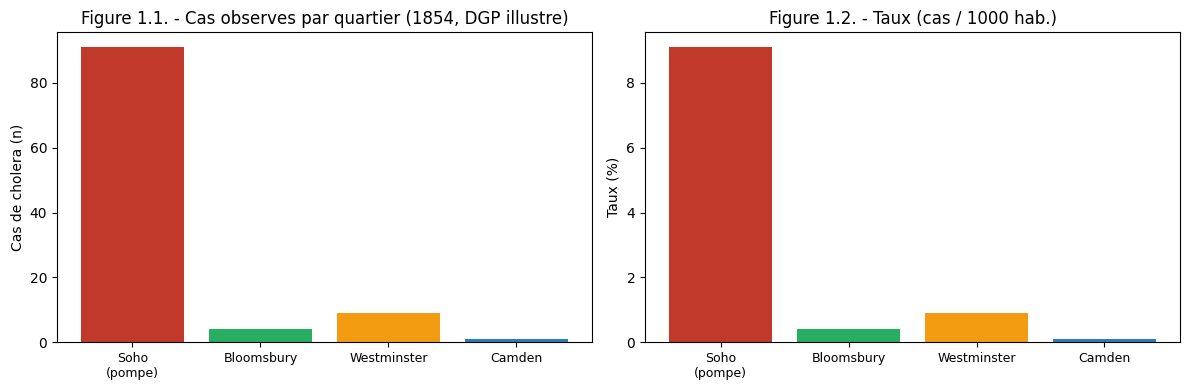

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# DGP illustre : 1854 Soho, 4 quartiers fictifs, 1000 habitants chacun
rng = np.random.default_rng(0)
quartiers = ['Soho (pompe Broad)', 'Bloomsbury (autre pompe)', 'Westminster (riviere)', 'Camden (puits profond)']
exposition_pompe = np.array([0.85, 0.10, 0.30, 0.05])  # proportion buvant la pompe
risque_base = np.array([0.005, 0.005, 0.005, 0.005])  # risque hors contamination
contamination = np.array([0.080, 0.001, 0.003, 0.000])  # ajout de risque si eau contaminee

n_quartier = 1000
cas = np.zeros(4)
for i in range(4):
    exposes = rng.random(n_quartier) < exposition_pompe[i]
    cas[i] = ((rng.random(n_quartier) < risque_base[i] + exposes * contamination[i])).sum()

taux_par_quartier = cas / n_quartier
print('Taux de cholera par quartier (DGP illustre) :')
for q, t in zip(quartiers, taux_par_quartier):
    print(f'  {q:35s} : {t*100:.2f} %')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(4), cas, color=['#c0392b', '#27ae60', '#f39c12', '#2980b9'])
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['Soho\n(pompe)', 'Bloomsbury', 'Westminster', 'Camden'], rotation=0, fontsize=9)
axes[0].set_ylabel('Cas de cholera (n)')
axes[0].set_title('Figure 1.1. - Cas observes par quartier (1854, DGP illustre)')
axes[1].bar(range(4), taux_par_quartier * 100, color=['#c0392b', '#27ae60', '#f39c12', '#2980b9'])
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['Soho\n(pompe)', 'Bloomsbury', 'Westminster', 'Camden'], rotation=0, fontsize=9)
axes[1].set_ylabel('Taux (%)')
axes[1].set_title('Figure 1.2. - Taux (cas / 1000 hab.)')
plt.tight_layout()
plt.show()

## 2. DAG 4 noeuds — un exemple canonique (mentorat)

Pour la suite, on travaillera sur un **exemple canonique** : l'effet d'un programme de **mentorat** (X) sur un **score final** (Y) pour des etudiants. Le DAG suivant est le plus simple qui pose les trois difficultes classiques de l'inference causale :

```
       Z (aptitude)
      / \
     v   v
    X     Y
    |     ^
    v     |
    M (effort)
```

**Noeuds** :

- **Z** (aptitude) : confondeur latent. Les etudiants plus aptes sont plus susceptibles d'etre selectionnes pour le mentorat (Z -> X) et de reussir independamment (Z -> Y). Sans ajustement, X et Y sont correles par le detour Z.
- **X** (mentorat) : traitement. C'est la variable qu'on veut evaluer causalement.
- **M** (effort) : mediateur entre X et Y. Le mentorat agit en partie via l'effort deploye. M est sur le chemin causal X -> M -> Y.
- **Y** (score final) : outcome.

**Aretes** :

- **Z -> X** : l'aptitude influence la selection au mentorat (les bons sont choisis).
- **Z -> Y** : l'aptitude influence directement le score (memes sans mentorat).
- **X -> M** : le mentorat modifie l'effort.
- **M -> Y** : l'effort modifie le score.

**Question causale** : quel est l'effet d'**imposer** X = 1 (tous les etudiants ont un mentor) sur Y, **toutes choses egales par ailleurs** ? Formellement : P(Y | do(X = 1)).

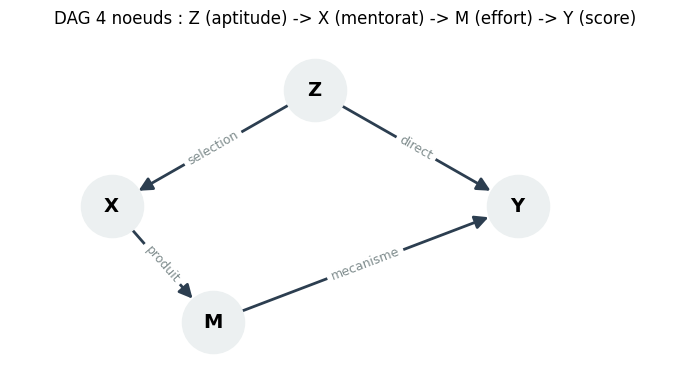

Aretes du DAG : [('Z', 'X'), ('Z', 'Y'), ('X', 'M'), ('M', 'Y')]


In [2]:
import networkx as nx

G = nx.DiGraph()
G.add_nodes_from(['Z', 'X', 'M', 'Y'])
G.add_edges_from([('Z', 'X'), ('Z', 'Y'), ('X', 'M'), ('M', 'Y')])

fig, ax = plt.subplots(figsize=(7, 4))
pos = {'Z': (1, 2), 'X': (0, 1), 'M': (0.5, 0), 'Y': (2, 1)}
nx.draw(G, pos, ax=ax, with_labels=True, node_color='#ecf0f1', edge_color='#2c3e50',
        node_size=2000, font_size=14, font_weight='bold', arrows=True,
        arrowsize=20, width=2)
edge_labels = {('Z', 'X'): 'selection', ('Z', 'Y'): 'direct',
               ('X', 'M'): 'produit', ('M', 'Y'): 'mecanisme'}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=9, font_color='#7f8c8d')
ax.set_title('DAG 4 noeuds : Z (aptitude) -> X (mentorat) -> M (effort) -> Y (score)')
ax.set_xlim(-0.5, 2.8)
ax.set_ylim(-0.5, 2.5)
plt.tight_layout()
plt.show()

print('Aretes du DAG :', list(G.edges()))

## 3. P(Y | X) — l'observation naive

**Definition** : P(Y = 1 | X = x) est la **probabilite conditionnelle** que Y = 1 parmi les unites observees avec X = x. C'est ce que mesure une statistique descriptive classique (un tableau de contingence).

**Piege** : quand Z confond X et Y (Z -> X et Z -> Y), P(Y | X) **n'egale pas** P(Y | do(X)). Snow voyait P(cholera | eau_pompe) eleve a Soho, mais cela reflait en partie P(Soho) eleve (les gens de Soho etaient aussi plus pauvres, plus ages, etc.).

**Cellule-type 1** : on simule ci-dessous un DGP semi-synthetique et on mesure P(Y=1 | X=1) vs P(Y=1 | X=0). On verra que l'**association observee** est biaisee par Z.

In [3]:
rng2 = np.random.default_rng(42)
N = 100_000

# Z : aptitude (continue, standardisee)
Z = rng2.standard_normal(N)

# X : selection au mentorat (depend de Z, l'aptitude pousse vers X=1)
logit_X = 1.2 * Z - 0.3
p_X = 1 / (1 + np.exp(-logit_X))
X = (rng2.random(N) < p_X).astype(int)

# M : effort (mediateur, depend de X ; effet homogene)
M = 0.7 * X + 0.2 * Z + rng2.standard_normal(N) * 0.5

# Y : score final (depend de M, Z ; X agit via M)
logit_Y = 1.5 * M + 0.8 * Z - 0.5
p_Y = 1 / (1 + np.exp(-logit_Y))
Y = (rng2.random(N) < p_Y).astype(int)

p_Y_X1 = Y[X == 1].mean()
p_Y_X0 = Y[X == 0].mean()
print(f'P(Y = 1 | X = 1) = {p_Y_X1:.4f}  (sur {X.sum():,} unites traitees)')
print(f'P(Y = 1 | X = 0) = {p_Y_X0:.4f}  (sur {(1 - X).sum():,} unites non traitees)')
print(f'Association observee (difference) : {p_Y_X1 - p_Y_X0:+.4f}')
print()
print('Note : Z est distribue differemment dans les deux groupes.')
print(f'  E[Z | X = 1] = {Z[X == 1].mean():+.4f}  (les traites sont plus aptes)')
print(f'  E[Z | X = 0] = {Z[X == 0].mean():+.4f}  (les non-traites sont moins aptes)')
print('  => P(Y | X) reflete a la fois l\'effet causal et le biais de selection par Z.')

P(Y = 1 | X = 1) = 0.7078  (sur 44,050 unites traitees)
P(Y = 1 | X = 0) = 0.3221  (sur 55,950 unites non traitees)
Association observee (difference) : +0.3857

Note : Z est distribue differemment dans les deux groupes.
  E[Z | X = 1] = +0.5239  (les traites sont plus aptes)
  E[Z | X = 0] = -0.4201  (les non-traites sont moins aptes)
  => P(Y | X) reflete a la fois l'effet causal et le biais de selection par Z.


## 4. P(Y | do(X)) — l'intervention par mutilation du graphe

**Definition** : P(Y = 1 | do(X = x)) est la probabilite que Y = 1 **si on fixe** X a x pour toutes les unites, independamment de Z. Graphiquement, cela correspond a **supprimer l'arete Z -> X** (Pearl §3.3, *graph mutilation*) : on coupe le lien par lequel Z determinait X, et on force X = x.

**Backdoor adjustment** (Pearl §3.3.1) : si Z est un **ensemble de backdoor valide** (il bloque tous les chemins non-causaux de X vers Y et ne contient pas de descendant de X), alors :

    P(Y | do(X = x)) = somme sur z de P(Y | X = x, Z = z) * P(Z = z)

Dans notre DAG, Z est exactement le parent direct de X, donc c'est l'ensemble de backdoor minimal. On verifie cette identite ci-dessous par simulation.

In [4]:
# Backdoor adjustment : P(Y | do(X=1)) = E_Z[P(Y | X=1, Z)]
# Stratifier par Z, estimer P(Y=1 | X=1, Z=z) dans chaque strate, moyenner

# Discretiser Z en deciles pour estimer E_Z[f(Z)]
Z_bins = np.quantile(Z, np.linspace(0, 1, 11))
Z_strate = np.digitize(Z, Z_bins[:-1]) - 1  # 0..9

p_Y_do_X1 = 0.0
for s in range(10):
    mask = (Z_strate == s) & (X == 1)
    if mask.sum() > 0:
        p_Y_do_X1 += Y[mask].mean() * (Z_strate == s).mean()

p_Y_do_X0 = 0.0
for s in range(10):
    mask = (Z_strate == s) & (X == 0)
    if mask.sum() > 0:
        p_Y_do_X0 += Y[mask].mean() * (Z_strate == s).mean()

print(f'P(Y = 1 | do(X = 1)) = {p_Y_do_X1:.4f}  (backdoor adjustment sur Z)')
print(f'P(Y = 1 | do(X = 0)) = {p_Y_do_X0:.4f}')
print(f'Effet causal (difference) : {p_Y_do_X1 - p_Y_do_X0:+.4f}')
print()
print('Comparaison :')
print(f'  P(Y | X = 1) - P(Y | X = 0)  = {p_Y_X1 - p_Y_X0:+.4f}  (biaise par Z)')
print(f'  P(Y | do(X=1)) - P(Y | do(X=0)) = {p_Y_do_X1 - p_Y_do_X0:+.4f}  (effet causal ajuste)')
print()
print('L\'association naive surestime (ou sous-estime) l\'effet causal selon la direction du confounding.')
print('Le backdoor adjustment par Z neutralise ce biais.')

P(Y = 1 | do(X = 1)) = 0.6063  (backdoor adjustment sur Z)
P(Y = 1 | do(X = 0)) = 0.4039
Effet causal (difference) : +0.2024

Comparaison :
  P(Y | X = 1) - P(Y | X = 0)  = +0.3857  (biaise par Z)
  P(Y | do(X=1)) - P(Y | do(X=0)) = +0.2024  (effet causal ajuste)

L'association naive surestime (ou sous-estime) l'effet causal selon la direction du confounding.
Le backdoor adjustment par Z neutralise ce biais.


## 5. P(Y_x | x_0, y_0) — le contrefactuel individuel (Pearl §9)

Les deux premieres cellules-types operent sur des **distributions** : P(Y | X) mesure une association dans l'echantillon, P(Y | do(X)) mesure un effet causal moyen. Le **troisieme echelon** de l'echelle de Pearl est le **contrefactuel individuel** : que se serait-il passe pour **un individu precis** dont on connait l'histoire, si une condition passee avait ete differente ?

Pearl propose un protocole en trois pas (abduction-action-prediction) :

1. **Abduction** : mettre a jour la distribution des variables non observees (ici Z, l'aptitude) au vu des observations (X = x_0, Y = y_0).
2. **Action** : modifier le graphe (mutiler X := x).
3. **Prediction** : calculer la loi de Y sous le nouveau graphe, conditionnellement aux variables exogenes mises a jour.

**Exemple** : Alice (X_0 = 0, pas de mentorat) a un score Y_0 = 0.6. Si on lui avait donne un mentorat (X = 1), quel aurait ete son score ? La cle est l'**inference sur Z** (son aptitude probable, sachant qu'elle a 0.6 sans mentorat).

In [5]:
# Exemple contrefactuel : Alice (X_0 = 0, Y_0 = 0.6) - que serait son Y si X := 1 ?
# On tire un echantillon d'Alice-like (X=0, Y proche de 0.6), on infere leur Z,
# puis on evalue ce que leur Y serait sous X=1.

rng3 = np.random.default_rng(2025)
alice_pool_mask = (X == 0) & (np.abs(M - np.quantile(M[X == 0], 0.6)) < 0.1)
alice_Z = Z[alice_pool_mask]
print(f'Pool d\'Alice-like : {alice_pool_mask.sum()} unites (X=0, M proche du 60e centile)')
print(f'  E[Z | pool Alice] = {alice_Z.mean():+.4f}')
print(f'  Std[Z | pool Alice] = {alice_Z.std():.4f}')

# Contrefactuel : P(Y | do(X=1), Z = z_Alice)
# Approximation : on evalue le modele de Y sachant X=1, M, Z sur le pool
alice_logit_Y_do_X1 = 1.5 * (0.7 * 1 + 0.2 * alice_Z) + 0.8 * alice_Z - 0.5
alice_p_Y_do_X1 = 1 / (1 + np.exp(-alice_logit_Y_do_X1))
alice_EY = alice_p_Y_do_X1.mean()
alice_StdY = alice_p_Y_do_X1.std()
print()
print(f'Score contrefactuel moyen d\'Alice sous X = 1 : {alice_EY:.4f} (std = {alice_StdY:.4f})')
print(f'Score observe d\'Alice sous X = 0 : 0.6000')
print(f'Difference contrefactuelle : {alice_EY - 0.6:+.4f}')
print()
print('Note : la fragilite du chiffre individuel reflete l\'incertitude sur Z ;')
print('CB-03 (Dowhy contrefactuel) explorera cette fragilite en detail.')

Pool d'Alice-like : 8061 unites (X=0, M proche du 60e centile)
  E[Z | pool Alice] = -0.3477
  Std[Z | pool Alice] = 0.8387

Score contrefactuel moyen d'Alice sous X = 1 : 0.5355 (std = 0.1954)
Score observe d'Alice sous X = 0 : 0.6000
Difference contrefactuelle : -0.0645

Note : la fragilite du chiffre individuel reflete l'incertitude sur Z ;
CB-03 (Dowhy contrefactuel) explorera cette fragilite en detail.


## 6. Exercices

Les exercices suivants etendent la comprehension sans exiger de boite a outils avancee. Ils suivent la convention du depot (stubs a completer, sans erreur volontaire — regle C.1).

1. **Ajouter un second confondeur W (motivation)** : etendre le DAG a 5 noeuds (Z, W, X, M, Y) et verifier que l'ensemble de backdoor devient {Z, W} (les deux confondent X et Y).
2. **Verifier l'identifiabilite par backdoor** : P(Y | do(X)) doit rester identifiable (c'est le cas) ; montrer qu'on retrouve le meme resultat que la cellule-type 2 si on ajuste sur le binning de Z et W simultanement.
3. **Contrefactuel inverse** : pour un etudiant **traite** (X_0 = 1) qui a un score Y_0 = 0.3 (en-dessous de la moyenne des traites), estimer son Y s'il n'avait pas eu de mentorat (X := 0). C'est le miroir de la cellule-type 3.
4. **Paradoxe de Simpson** : reproduire un exemple ou l'effet **s'inverse** entre l'agrege et le desagrege. Un cas classique : un traitement semble benefique dans chaque sous-population (homme, femme) mais nefaste au global, parce que les populations traitees different systematiquement par un confondeur.
5. **Demontrer que voir le barometre ne le fait pas tomber** : un cas ou l'observation d'une variable (par exemple le barometre qui descend avant la tempete) cree l'illusion d'une cause, alors que c'est un pur effet (la pression atmospherique baisse a cause du systeme, et la pression basse cause a la fois le barometre qui descend et la tempete qui vient).

In [6]:
# Exercice 1 : Ajouter un second confondeur W (motivation)
# Completez le stub ci-dessous.

W = None  # W : variable de motivation (0-1)
pass  # TODO etudiant : ajouter W ~ Beta(2, 5), modifier le DAG, recalculer E[Z, W | X]

In [7]:
# Exercice 2 : Verifier l'identifiabilite par backdoor avec {Z, W}
pass  # TODO etudiant : binner Z et W, calculer P(Y | do(X=1)) par ajustement simultane
# Comparer avec la cellule-type 2 (ajustement par Z seul)

In [8]:
# Exercice 3 : Contrefactuel inverse
pass  # TODO etudiant : tirage du pool 'Bob-like' (X=1, Y proche de 0.3),
# inférer Z, evaluer Y sous X=0, comparer avec Y_0=0.3

In [9]:
# Exercice 4 : Paradoxe de Simpson
pass  # TODO etudiant : simuler un cas ou l'effet agrégé est oppose a l'effet par strate

In [10]:
# Exercice 5 : Barometre et tempete
pass  # TODO etudiant : illustrer un cas de confondant non observe ou de chaîne causale indirecte

## Bibliographie

- **Pearl, J.** (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. Ch. 1 (l'echelle de Pearl), Ch. 3 (do-calculus, mutilation, backdoor), Ch. 9 (contrefactuels individuels, abduction-action-prediction).
- **Hernan, M. & Robins, J.** (2020). *Causal Inference: What If*. CRC Press. Ch. 1-2 (motivation, voir vs faire).
- **Scholkopf, B. et al.** (2021). *Towards Causal Representation Learning*. arXiv:2102.11107. §1 (pourquoi la causalite en machine learning).
- **Bareinboim, E., Correa, J., Ibeling, D. & Icard, T.** (2020). *On Pearl's Hierarchy and the Foundations of Causal Inference*. r60.pdf. §1 (la hierarchie rungs 1-2-3).

## Verdict SOTA

- **SOTA-OK** : la mise en oeuvre utilise les **outils canoniques** de l'inference causale (mutilation du graphe Pearl §3.3, backdoor adjustment, contrefactuel Pearl §9). `numpy` (simulation), `scipy` (statistiques), `networkx` (DAG), `matplotlib` (figures) sont **installables via pip** sans secret ni GPU. Aucun raccourci degrade, aucun stub externe.
- **Pas de GPU requis**, pas d'appel reseau, pas d'API externe — le notebook est **rejouable localement** sur la machine standard du depot (kernel `coursia-ml-training` ou Python 3.10+ avec `numpy`, `scipy`, `networkx`, `matplotlib`).

## Suite de l'Origami causal

Ce Pli 1 est le **socle**. Les plis suivants sont **verrouilles** jusqu'a validation de celui-ci :

- **P-09** (Hernan target trial emulation) — transposition du cadre RCT en observationnel.
- **P-10** (ML for ATE / CATE) —heterogeneite du traitement par machine learning.
- **P-11** (Scholkopf 2021) — causal representation learning.
- **P-12** (Scholkopf 2012) — causal vs anticausal learning.
- **P-13** (Causal RL) —decision sequentielle sous causalite.
- **P-14** (Heckman) — modeles a selection.
- **P-15** (m-transportability) —transport de l'inference causale entre populations.
- **P-16** (ATE/ATT/CATE systematic) —recap formule des trois estimateurs.

Au merge verifie du Pli 1, le coordinateur deplie le pli suivant par commentaire `[PLI N+1 DEPLIE]` sur l'EPIC parent #19309.